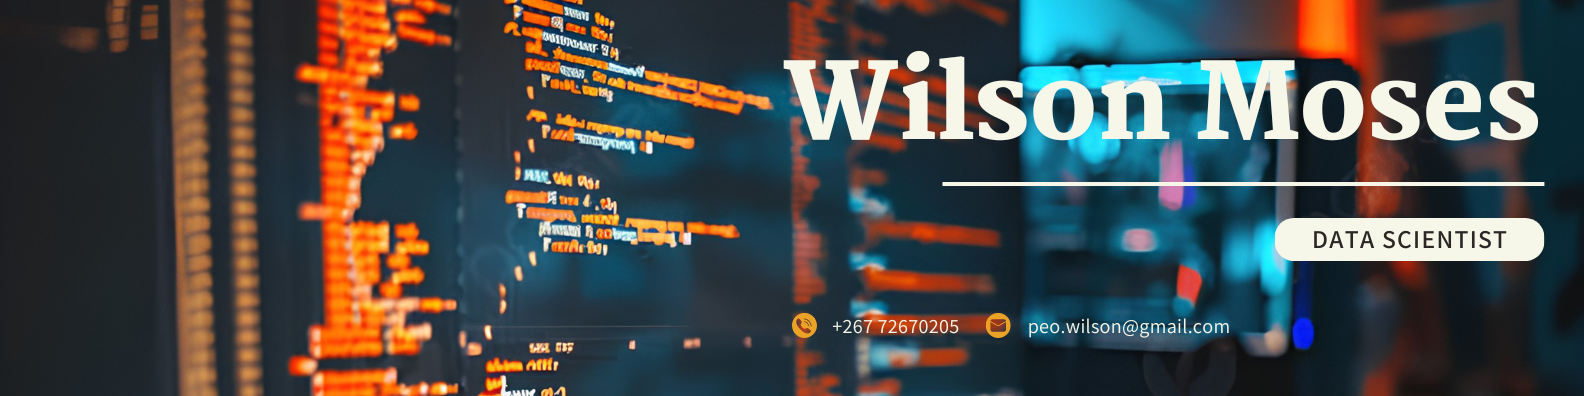

# Loan Prediction Data Preparation: Data Inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from narwhals.typing import CorrelationMethod

## Load Dataset

In [2]:
data = pd.read_csv('Prediction_Loan_Train.csv')
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## What Information is in this data? - Data Types

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## What is the shape of the data? - Rows & Columns

In [4]:
data.shape

(614, 13)

## Are there any duplicate records?

In [5]:
data.duplicated().sum()


np.int64(0)

**_No duplicate records were identified; therefore, no duplicate observations were removed._**

## Statistical Description - Summary Statistic

In [6]:
data.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Data Inspections

### Missing Values

In [7]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Investigate Categorical Missing Values

#### Gender

In [8]:
data['Gender'].value_counts(dropna = False)


Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

#### Married

In [9]:
data['Married'].value_counts(dropna=False)

Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

#### Dependents

In [10]:
data['Dependents'].value_counts(dropna=False)


Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

### Self Employed

In [11]:
data['Self_Employed'].value_counts(dropna=False)


Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

### Investigate Numerical Missing Values

#### Loan Amount & Loan_Amount_Term

In [12]:
data[['LoanAmount', 'Loan_Amount_Term']].describe()

,LoanAmount,Loan_Amount_Term
count,592.000000,600.00000
mean,146.412162,342.00000
std,85.587325,65.12041
min,9.000000,12.00000
25%,100.000000,360.00000
50%,128.000000,360.00000
75%,168.000000,360.00000
max,700.000000,480.00000


In [13]:
data['LoanAmount'].median()

np.float64(128.0)

In [14]:
data['LoanAmount'].mean()

np.float64(146.41216216216216)

### Credit History

In [15]:
data['Credit_History'].value_counts(dropna=False)

Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

### Numerical Distributions

In [16]:
data[['ApplicantIncome',
      'CoapplicantIncome',
      'LoanAmount',
      'Loan_Amount_Term']].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


## Data Cleaning Preparation

### Gender - Mode Imputation

In [17]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

Missing Gender values were imputed using the mode because Gender is a categorical variable and only a small proportion of observations were missing. Mode imputation allows the affected observations to be retained without introducing a new category.

### Married - Mode Imputation

In [18]:
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

Again, because it is categorical and the number of missing observations is extremely small.

### Dependents - Mode Imputation

In [19]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

### Self Employed - Mode Imputation

In [20]:
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

Missing values represented approximately 5.2% of observations. Since Self_Employed is categorical and the majority of observed applicants were not self-employed, mode imputation was selected to retain observations while avoiding unnecessary row deletion.

### Loan Amount - Median Imputation

In [21]:
data['LoanAmount'] = data['LoanAmount'].fillna(
    data['LoanAmount'].median()
)

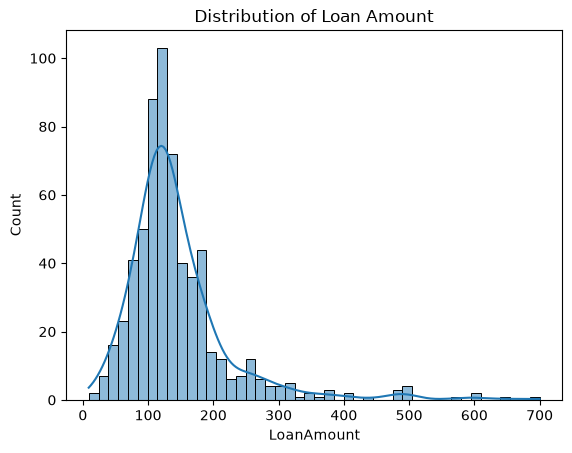

In [22]:
sns.histplot(data['LoanAmount'], kde=True)
plt.title('Distribution of Loan Amount')
plt.show()

"The distribution contains extreme observations, so median imputation is a more robust choice for missing LoanAmount values."

### Loan_Amount_Term - Mode Imputation

In [23]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(
    data['Loan_Amount_Term'].mode()[0]
)

In [24]:
data['Loan_Amount_Term'].value_counts(dropna=False)

Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

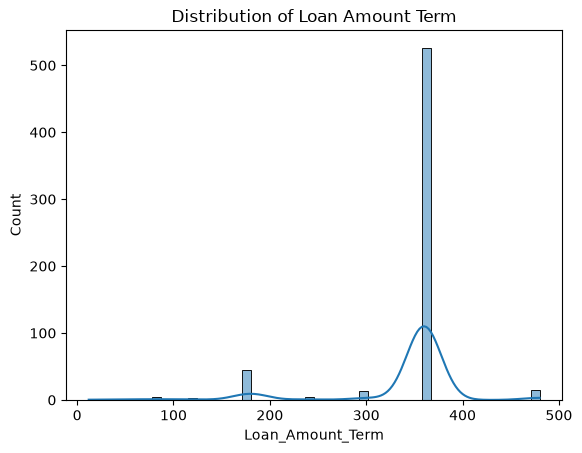

In [25]:
sns.histplot(data['Loan_Amount_Term'], kde=True)
plt.title('Distribution of Loan Amount Term')
plt.show()

Loan_Amount_Term represents a discrete loan term, and the most common actual term is more meaningful than calculating an average term.


Credit_History

In [26]:
data['Credit_History'].fillna(1)

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

In [27]:
data.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True)

Credit_History  Loan_Status
0.0             N              0.921348
                Y              0.078652
1.0             Y              0.795789
                N              0.204211
Name: proportion, dtype: float64

## Cleaning Implementation

In [28]:
# Categorical variables
categorical_mode_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for column in categorical_mode_columns:
    data[column] = data[column].fillna(data[column].mode()[0])

# Numerical/discrete variables
data['LoanAmount'] = data['LoanAmount'].fillna(
    data['LoanAmount'].median()
)

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(
    data['Loan_Amount_Term'].mode()[0]
)

# Binary categorical variable
data['Credit_History'] = data['Credit_History'].fillna(
    data['Credit_History'].mode()[0]
)

### Verify the Cleaning

In [29]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [30]:
data.duplicated().sum()

np.int64(0)

In [31]:
data.shape

(614, 13)

# Feature Engineering

1. Can I represent the existing information better?
2. Can I create a variable that captures useful business meaning?
3. Are there variables that shouldn't go into the model?

## Remove Loan_ID

In [32]:
data = data.drop(columns=['Loan_ID'])

## Create TotalIncome - ApplicantIncome + CoapplicantIncome

In [33]:
data['TotalIncome'] = (
    data['ApplicantIncome'] +
    data['CoapplicantIncome']
)

## Create LoanIncomeRatio

### First check whether TotalIncome contains zero

In [34]:
(data['TotalIncome'] == 0).sum()

np.int64(0)

In [35]:
data['LoanIncomeRatio'] = (
    data['LoanAmount'] / data['TotalIncome']
)

## Rename Columns

In [36]:
data = data.rename(columns={
    'Gender': 'gender',
    'Married': 'married',
    'Dependents': 'dependents',
    'Education': 'education',
    'Self_Employed': 'self_employed',
    'ApplicantIncome': 'applicant_income',
    'CoapplicantIncome': 'coapplicant_income',
    'LoanAmount': 'loan_amount',
    'Loan_Amount_Term': 'loan_amount_term',
    'Credit_History': 'credit_history',
    'Property_Area': 'property_area',
    'Loan_Status': 'loan_status',
    'TotalIncome': 'total_income',
    'LoanIncomeRatio': 'loan_income_ratio'
})

## Checking Resulting Dataset

In [37]:
data.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicant_income', 'coapplicant_income', 'loan_amount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status',
       'total_income', 'loan_income_ratio'],
      dtype='str')

## Check the Engineered features

In [38]:
data[['applicant_income',
      'coapplicant_income',
      'total_income',
      'loan_amount',
      'loan_income_ratio']].head(10)

,applicant_income,coapplicant_income,total_income,loan_amount,loan_income_ratio
0,5849,0.0,5849.0,128.0,0.021884
1,4583,1508.0,6091.0,128.0,0.021015
2,3000,0.0,3000.0,66.0,0.022000
3,2583,2358.0,4941.0,120.0,0.024287
4,6000,0.0,6000.0,141.0,0.023500
5,5417,4196.0,9613.0,267.0,0.027775
6,2333,1516.0,3849.0,95.0,0.024682
7,3036,2504.0,5540.0,158.0,0.028520
8,4006,1526.0,5532.0,168.0,0.030369
9,12841,10968.0,23809.0,349.0,0.014658


## Check Engineered feature Statistics

In [39]:
data[['total_income', 'loan_income_ratio']].describe()

,total_income,loan_income_ratio
count,614.000000,614.000000
mean,7024.705081,0.023877
std,6458.663872,0.008707
min,1442.000000,0.002523
25%,4166.000000,0.019221
50%,5416.500000,0.024129
75%,7521.750000,0.028158
max,81000.000000,0.082712


## Produce Cleaned Dataset

In [40]:
cleaned_data = data.copy()

In [41]:
cleaned_data.isnull().sum()

gender                0
married               0
dependents            0
education             0
self_employed         0
applicant_income      0
coapplicant_income    0
loan_amount           0
loan_amount_term      0
credit_history        0
property_area         0
loan_status           0
total_income          0
loan_income_ratio     0
dtype: int64

In [42]:
cleaned_data.to_csv(
    'loan_prediction_cleaned.csv',
    index=False
)

In [43]:
import os

os.path.exists('loan_prediction_cleaned.csv')

True

# Feauture Encoding

## Binary Categorical Variables

### Gender - Binary encoding

In [44]:
data['gender'] = data['gender'].map({
    'Male': 1,
    'Female': 0
})

### Married - Binary encoding

In [45]:
data['married'] = data['married'].map({
    'Yes': 1,
    'No': 0
})

### Education - Binary encoding

In [46]:
data['education'] = data['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

### Self Employed - Binary encoding

In [47]:
data['self_employed'] = data['self_employed'].map({
    'Yes': 1,
    'No': 0
})

### Credit History

Convert it to int from float - Data type correction

In [48]:
data['credit_history'] = data['credit_history'].astype(int)

### Dependents - Custom numerical encoding

In [49]:
data['dependents'] = data['dependents'].replace({
    '3+': '3'
}).astype(int)

Important note:

3 doesn't mean exactly three dependents. It effectively means: three or more dependents

### Property Area - dummy-variable encoding.

In [50]:
data = pd.get_dummies(
    data,
    columns=['property_area'],
    drop_first=True,
    dtype=int
)

This will produce two columns rather than three. with rural acting as the refernce category

### Encoding the target: Loan Status - Binary Encoding

In [51]:
data['loan_status'] = data['loan_status'].map({
    'Y': 1,
    'N': 0
})

### Verify the results

In [52]:
data.head()

,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,loan_status,total_income,loan_income_ratio,property_area_Semiurban,property_area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1,1,5849.0,0.021884,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,6091.0,0.021015,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1,1,3000.0,0.022000,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1,1,4941.0,0.024287,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1,1,6000.0,0.023500,0,1


In [53]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   614 non-null    int64  
 1   married                  614 non-null    int64  
 2   dependents               614 non-null    int64  
 3   education                614 non-null    int64  
 4   self_employed            614 non-null    int64  
 5   applicant_income         614 non-null    int64  
 6   coapplicant_income       614 non-null    float64
 7   loan_amount              614 non-null    float64
 8   loan_amount_term         614 non-null    float64
 9   credit_history           614 non-null    int64  
 10  loan_status              614 non-null    int64  
 11  total_income             614 non-null    float64
 12  loan_income_ratio        614 non-null    float64
 13  property_area_Semiurban  614 non-null    int64  
 14  property_area_Urban      614 non-null

In [54]:
data.dtypes

gender                       int64
married                      int64
dependents                   int64
education                    int64
self_employed                int64
applicant_income             int64
coapplicant_income         float64
loan_amount                float64
loan_amount_term           float64
credit_history               int64
loan_status                  int64
total_income               float64
loan_income_ratio          float64
property_area_Semiurban      int64
property_area_Urban          int64
dtype: object

In [55]:
data['dependents'].value_counts()

dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64

In [56]:
data.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicant_income', 'coapplicant_income', 'loan_amount',
       'loan_amount_term', 'credit_history', 'loan_status', 'total_income',
       'loan_income_ratio', 'property_area_Semiurban', 'property_area_Urban'],
      dtype='str')

# Feature Scaling

## Inspection of numerical variables

In [57]:
numerical_features = [
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'loan_amount_term',
    'total_income',
    'loan_income_ratio'
]

data[numerical_features].describe()

,applicant_income,coapplicant_income,loan_amount,loan_amount_term,total_income,loan_income_ratio
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,7024.705081,0.023877
std,6109.041673,2926.248369,84.107233,64.428629,6458.663872,0.008707
min,150.000000,0.000000,9.000000,12.000000,1442.000000,0.002523
25%,2877.500000,0.000000,100.250000,360.000000,4166.000000,0.019221
50%,3812.500000,1188.500000,128.000000,360.000000,5416.500000,0.024129
75%,5795.000000,2297.250000,164.750000,360.000000,7521.750000,0.028158
max,81000.000000,41667.000000,700.000000,480.000000,81000.000000,0.082712


## Apply StandardScaler

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data[numerical_features] = scaler.fit_transform(
    data[numerical_features]
)

### Verify Scaling

In [59]:
data[numerical_features].describe()

,applicant_income,coapplicant_income,loan_amount,loan_amount_term,total_income,loan_income_ratio
count,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02
mean,-4.339634e-18,4.050325e-17,-2.603780e-17,5.930833e-17,1.157236e-16,3.240260e-16
std,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00
min,-8.606493e-01,-5.544873e-01,-1.627255e+00,-5.132498e+00,-8.650794e-01,-2.454449e+00
25%,-4.138159e-01,-5.544873e-01,-5.414462e-01,2.732313e-01,-4.429764e-01,-5.351952e-01
50%,-2.606393e-01,-1.480047e-01,-2.112412e-01,2.732313e-01,-2.492027e-01,2.901382e-02
75%,6.414426e-02,2.312023e-01,2.260572e-01,2.732313e-01,7.702060e-02,4.920920e-01
max,1.238462e+01,1.369617e+01,6.595146e+00,2.137276e+00,1.146299e+01,6.762575e+00


## Outlier detection

### Box Plot of Numerical Features

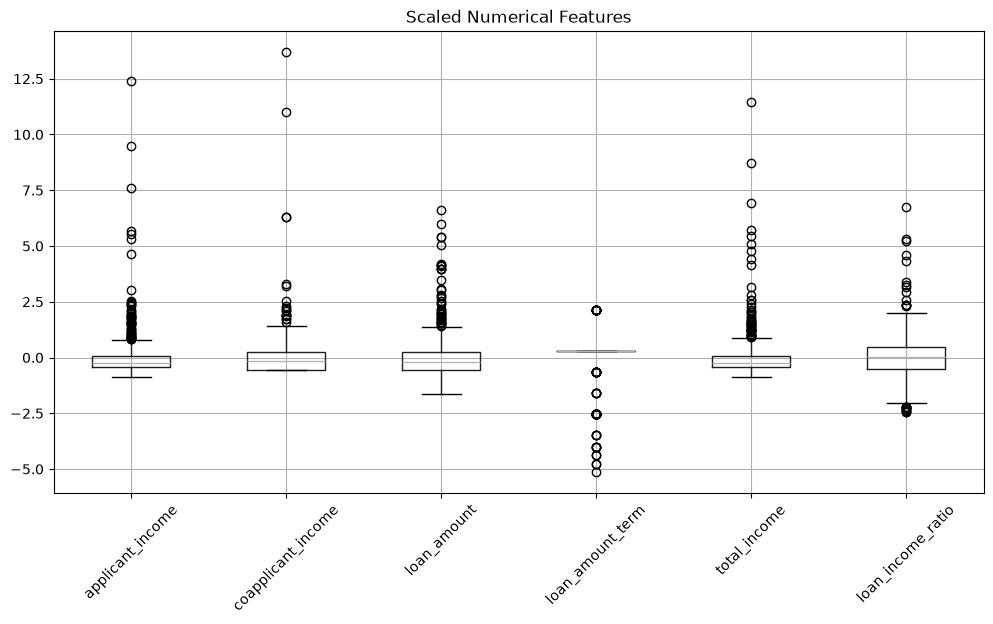

In [60]:
data[numerical_features].boxplot(figsize=(12, 6))
plt.title('Scaled Numerical Features')
plt.xticks(rotation=45)
plt.show()

### IQR Method

In [61]:
numerical_features = [
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'loan_amount_term',
    'total_income',
    'loan_income_ratio'
]

for column in numerical_features:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    if IQR == 0:
        print(f'{column}')
        print('IQR = 0; IQR-based outlier detection is not informative.')
        print('-' * 40)
        continue

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f'{column}')
    print(f'IQR: {IQR:.3f}')
    print(f'Lower bound: {lower_bound:.3f}')
    print(f'Upper bound: {upper_bound:.3f}')
    print(f'Number of outliers: {len(outliers)}')
    print('-' * 40)

applicant_income
IQR: 0.478
Lower bound: -1.131
Upper bound: 0.781
Number of outliers: 50
----------------------------------------
coapplicant_income
IQR: 0.786
Lower bound: -1.733
Upper bound: 1.410
Number of outliers: 18
----------------------------------------
loan_amount
IQR: 0.768
Lower bound: -1.693
Upper bound: 1.377
Number of outliers: 41
----------------------------------------
loan_amount_term
IQR = 0; IQR-based outlier detection is not informative.
----------------------------------------
total_income
IQR: 0.520
Lower bound: -1.223
Upper bound: 0.857
Number of outliers: 50
----------------------------------------
loan_income_ratio
IQR: 1.027
Lower bound: -2.076
Upper bound: 2.033
Number of outliers: 25
----------------------------------------


# Feature Selection
1. Which Variables are most relevant?
2. Which variables are redundant?
3. Which features should ultimately be removed?

## We will use three forms of evidence:
1. Correlation
2. Feature Importance
3. Business/feature Logic

### Step 1: Seperate X & Y

In [62]:
x = data.drop(columns=['loan_status'])
y = data['loan_status']

In [63]:
x.shape

(614, 14)

In [64]:
y.shape

(614,)

### Step 2: Correlation Heatmap

In [65]:
correlation_matrix = data.corr()

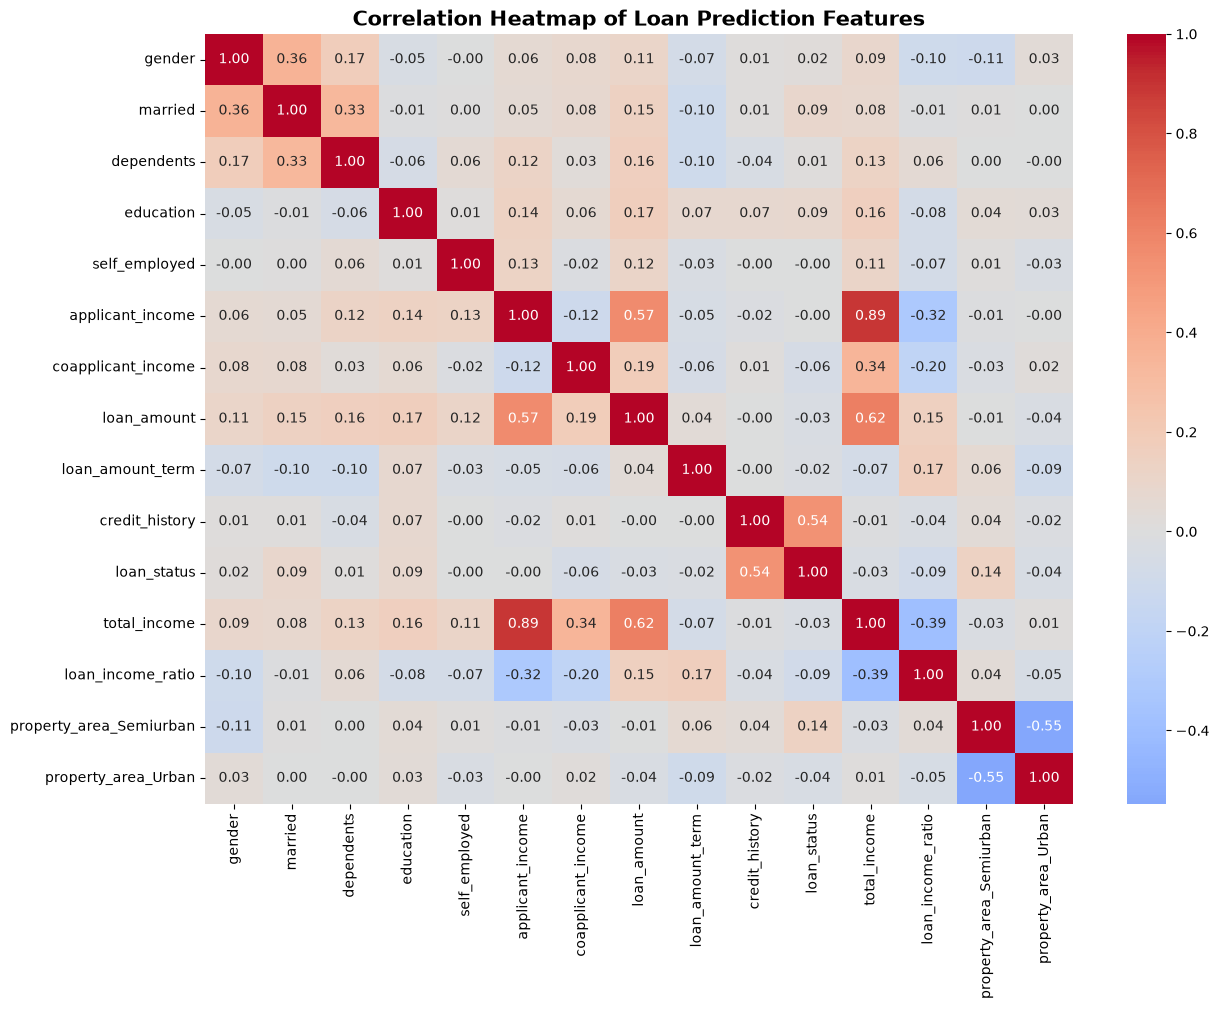

In [66]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Loan Prediction Features', fontsize=15, fontweight='bold')
plt.show()


## Investigate redundancy


In [67]:
data[
    [
        'applicant_income',
        'coapplicant_income',
        'total_income',
        'loan_amount',
        'loan_income_ratio'
    ]
].corr()

,applicant_income,coapplicant_income,total_income,loan_amount,loan_income_ratio
applicant_income,1.000000,-0.116605,0.893037,0.565181,-0.317468
coapplicant_income,-0.116605,1.000000,0.342781,0.189218,-0.201101
total_income,0.893037,0.342781,1.000000,0.620316,-0.391396
loan_amount,0.565181,0.189218,0.620316,1.000000,0.152830
loan_income_ratio,-0.317468,-0.201101,-0.391396,0.152830,1.000000


## Identify High Correlated pairs

In [68]:
corr_matrix = x.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs[high_corr_pairs >= 0.80]

applicant_income  total_income    0.893037
dtype: float64

## Step 3 - Examine feature relationships with loan_status

In [69]:
target_correlation = (
    data.corr()['loan_status']
    .drop('loan_status')
    .sort_values(key=abs, ascending=False)
)

target_correlation

credit_history             0.540556
property_area_Semiurban    0.136540
married                    0.091478
loan_income_ratio         -0.086141
education                  0.085884
coapplicant_income        -0.059187
property_area_Urban       -0.043621
loan_amount               -0.033214
total_income              -0.031271
loan_amount_term          -0.022549
gender                     0.017987
dependents                 0.010118
applicant_income          -0.004710
self_employed             -0.003700
Name: loan_status, dtype: float64

## Step 4 - Visualize the target relationship

### Loan Status with Applicant Income

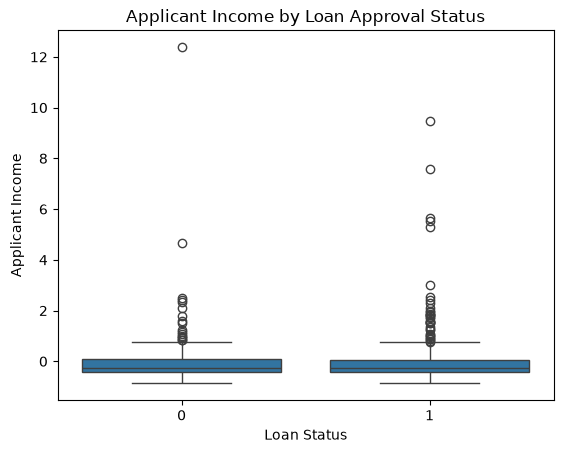

In [70]:
sns.boxplot(
    x='loan_status',
    y='applicant_income',
    data=data
)

plt.title('Applicant Income by Loan Approval Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()

### For: Loan Amount, Total Income and Loan Income Ratio

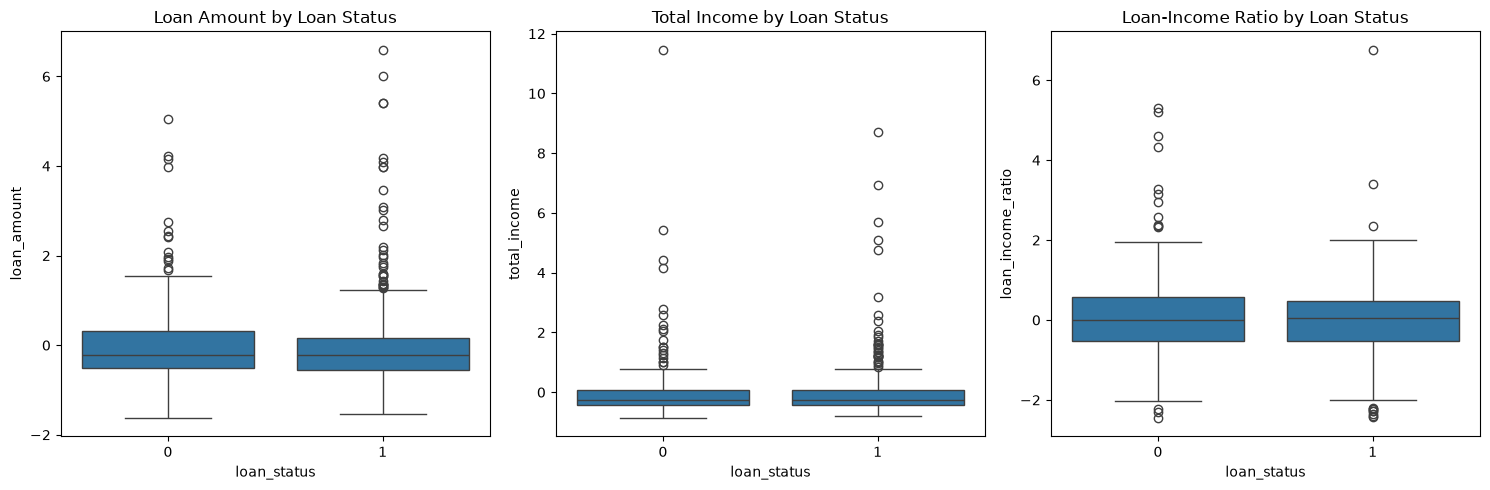

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    x='loan_status',
    y='loan_amount',
    data=data,
    ax=axes[0]
)

sns.boxplot(
    x='loan_status',
    y='total_income',
    data=data,
    ax=axes[1]
)

sns.boxplot(
    x='loan_status',
    y='loan_income_ratio',
    data=data,
    ax=axes[2]
)

axes[0].set_title('Loan Amount by Loan Status')
axes[1].set_title('Total Income by Loan Status')
axes[2].set_title('Loan-Income Ratio by Loan Status')

plt.tight_layout()
plt.show()

## Step 5 - Categorical/binary feature relationships

### Credit History

In [72]:
credit_history_approval = pd.crosstab(
    data['credit_history'],
    data['loan_status'],
    normalize='index'
)

credit_history_approval

loan_status,0,1
credit_history,,
0,0.921348,0.078652
1,0.209524,0.790476


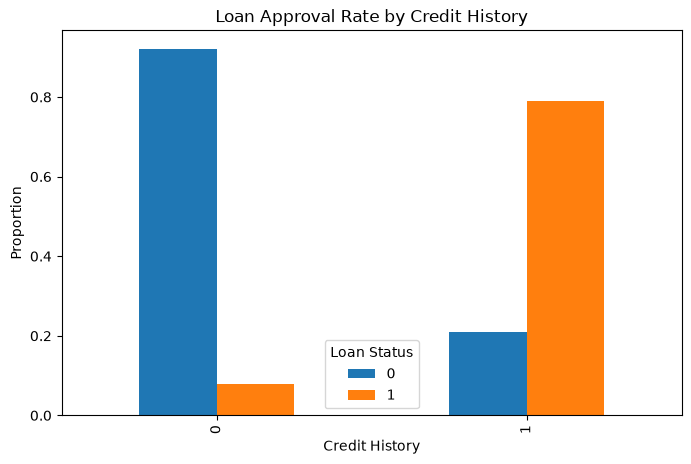

In [73]:
credit_history_approval.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Loan Approval Rate by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Proportion')
plt.legend(title='Loan Status')
plt.show()

## Step 6 - Feature Importance

**We'll use a Random Forest Classifier**

### Train/test split

In [74]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['loan_status'])
y = data['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Build the Random Forest

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

We are trying to build a tool for understanding feature importance

## Extract Feature Importance

In [76]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance

,feature,importance
9,credit_history,0.223215
11,loan_income_ratio,0.138606
10,total_income,0.130596
5,applicant_income,0.125723
7,loan_amount,0.120234
6,coapplicant_income,0.079149
2,dependents,0.037981
8,loan_amount_term,0.036726
12,property_area_Semiurban,0.022679
3,education,0.020211


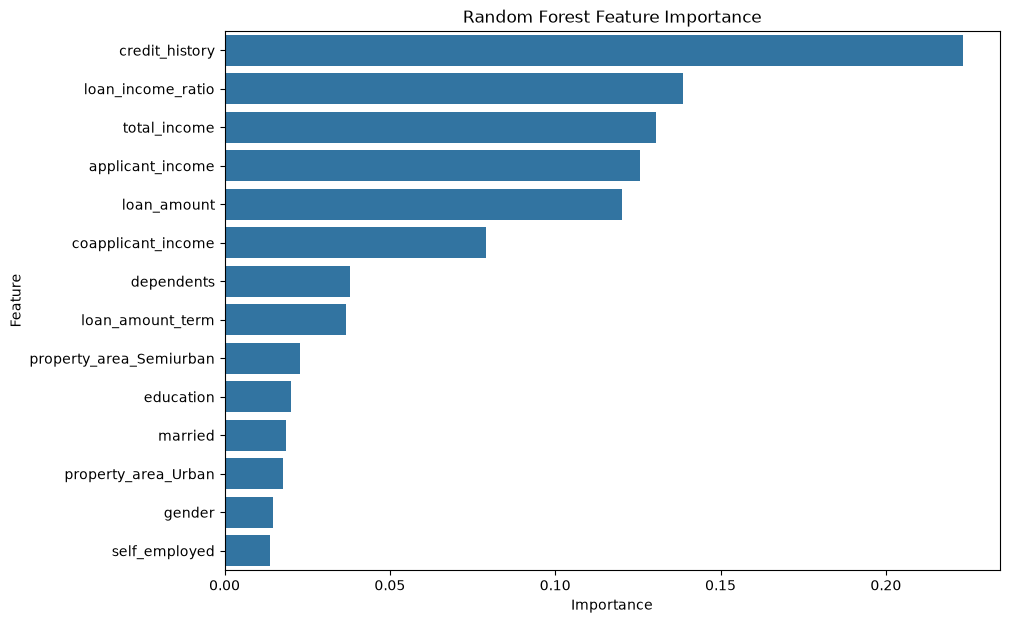

In [77]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

## ML-Ready dataset

In [78]:
model_data = cleaned_data.drop(
    columns=['applicant_income']
)

model_data.to_csv(
    'loan_prediction_ml_ready.csv',
    index=False
)

## Preprocessing Summary

In [79]:
print("CLEANED DATASET")
print("=" * 40)
print(f"Rows: {cleaned_data.shape[0]}")
print(f"Columns: {cleaned_data.shape[1]}")
print(f"Missing values: {cleaned_data.isnull().sum().sum()}")
print(f"Duplicate rows: {cleaned_data.duplicated().sum()}")

print("\nML-READY DATASET")
print("=" * 40)
print(f"Rows: {model_data.shape[0]}")
print(f"Columns: {model_data.shape[1]}")
print(f"Missing values: {model_data.isnull().sum().sum()}")
print(f"Duplicate rows: {model_data.duplicated().sum()}")

CLEANED DATASET
Rows: 614
Columns: 14
Missing values: 0
Duplicate rows: 0

ML-READY DATASET
Rows: 614
Columns: 13
Missing values: 0
Duplicate rows: 0
